# Load data from InfluxDB

In [179]:
%pip install influxdb-client


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [180]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "nIFNlhkdcuc8p7zn-zR5X0aHrMUhzEKEmcsne4YRugOvoWBTgzpeSl2SsBJp8buZJ-wR9jRXVzL7py6v23_KMw=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [194]:
# 1. Define the dynamic variables in the params dictionary
time_start = "-10m"
time_stop = "now()"
window = "1s"

# 2. Define the query using the v.variable syntax
query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(q|qd)_actual_joint_[0-5]/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

query_ctrl_msgs = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
'''

# 3. Execute and return as a DataFrame
df_sensor_data = query_api.query_data_frame(query_sensor_data)
df_ctrl_msgs = query_api.query_data_frame(query_ctrl_msgs)




/home/losmobilos3/Desktop/Engineering Digital Twins/UR3eDTCourse/.venv/lib/python3.11/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "ur3e")
  |> range(start: -10m, stop: now())
  |> filter(fn: (r) => r["_measurement"] == "ctrl_msgs")
  |> filter(fn: (r) => r["_field"] == "msg_type")
  |> filter(fn: (r) => r["msg_type"] == "play")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/inf

# Show data

In [195]:
print(df_ctrl_msgs.head())

    result  table                           _start  \
0  _result      0 2026-03-06 14:54:16.164448+00:00   
1  _result      0 2026-03-06 14:54:16.164448+00:00   
2  _result      0 2026-03-06 14:54:16.164448+00:00   
3  _result      0 2026-03-06 14:54:16.164448+00:00   
4  _result      0 2026-03-06 14:54:16.164448+00:00   

                             _stop                            _time _value  \
0 2026-03-06 15:04:16.164448+00:00 2026-03-06 14:55:33.118540+00:00   play   
1 2026-03-06 15:04:16.164448+00:00 2026-03-06 14:57:13.124316+00:00   play   
2 2026-03-06 15:04:16.164448+00:00 2026-03-06 14:58:53.118760+00:00   play   
3 2026-03-06 15:04:16.164448+00:00 2026-03-06 15:00:33.122047+00:00   play   
4 2026-03-06 15:04:16.164448+00:00 2026-03-06 15:02:13.124618+00:00   play   

     _field _measurement msg_type                 source  
0  msg_type    ctrl_msgs     play  data_recorder_service  
1  msg_type    ctrl_msgs     play  data_recorder_service  
2  msg_type    ctrl_msgs     

In [197]:
print(df_sensor_data.head())


    result  table                            _time  \
0  _result      0 2026-03-06 14:54:15.974849+00:00   
1  _result      0 2026-03-06 14:54:16.028567+00:00   
2  _result      0 2026-03-06 14:54:16.078909+00:00   
3  _result      0 2026-03-06 14:54:16.129704+00:00   
4  _result      0 2026-03-06 14:54:16.179733+00:00   

                            _start                            _stop  \
0 2026-03-06 14:54:15.947068+00:00 2026-03-06 15:04:15.947068+00:00   
1 2026-03-06 14:54:15.947068+00:00 2026-03-06 15:04:15.947068+00:00   
2 2026-03-06 14:54:15.947068+00:00 2026-03-06 15:04:15.947068+00:00   
3 2026-03-06 14:54:15.947068+00:00 2026-03-06 15:04:15.947068+00:00   
4 2026-03-06 14:54:15.947068+00:00 2026-03-06 15:04:15.947068+00:00   

  _measurement                 source  q_actual_joint_0  q_actual_joint_1  \
0  sensor_data  data_recorder_service         -9.604144         -2.231468   
1  sensor_data  data_recorder_service         -9.604144         -2.231468   
2  sensor_data  d

In [198]:
sensor_data_np = df_sensor_data.to_numpy()
start_msgs_timestamps = df_ctrl_msgs["_time"].to_list()

In [199]:
sensor_data_np.shape

(11950, 19)

In [200]:
sensor_data_np[0, :]

array(['_result', 0,
       Timestamp('2026-03-06 14:54:15.974849+0000', tz='UTC'),
       Timestamp('2026-03-06 14:54:15.947068+0000', tz='UTC'),
       Timestamp('2026-03-06 15:04:15.947068+0000', tz='UTC'),
       'sensor_data', 'data_recorder_service', -9.604144203014933,
       -2.2314681882873857, -11.18512291462037, 10.598092858317838,
       -5.795068806531225, -6.612751667017492, 0.0, 0.0, 0.0, 0.0,
       -2.842170943040401e-14, -5.684341886080802e-14], dtype=object)

In [201]:
start_msgs_timestamps

[Timestamp('2026-03-06 14:55:33.118540+0000', tz='UTC'),
 Timestamp('2026-03-06 14:57:13.124316+0000', tz='UTC'),
 Timestamp('2026-03-06 14:58:53.118760+0000', tz='UTC'),
 Timestamp('2026-03-06 15:00:33.122047+0000', tz='UTC'),
 Timestamp('2026-03-06 15:02:13.124618+0000', tz='UTC'),
 Timestamp('2026-03-06 15:03:53.126418+0000', tz='UTC')]

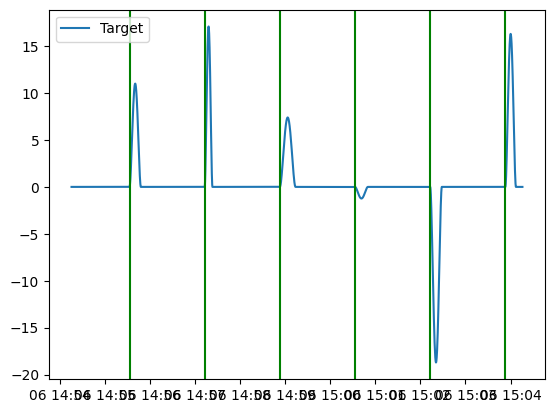

In [202]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, 2], sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for movement_start in start_msgs_timestamps:
    plt.axvline(movement_start, color="g")

plt.legend()

# Determine end of movements
From observing the PT mockup, we have determined that all joints take the same amount of time to move.

In [189]:
import copy
# Translate timestamps into indexes
start_indexes = []
start_timestamps = copy.deepcopy(start_msgs_timestamps)

for n in range(sensor_data_np.shape[0] - 1):
    time_at_n = sensor_data_np[n, 2]
    time_at_n_plus_1 = sensor_data_np[n+1, 2]
    if time_at_n <= start_timestamps[0] <= time_at_n_plus_1:
        start_indexes.append(n)
        start_timestamps.pop(0)
    if len(start_timestamps) == 0:
        break

In [190]:
start_indexes

[824, 2814, 4806, 6798, 8789, 10782]

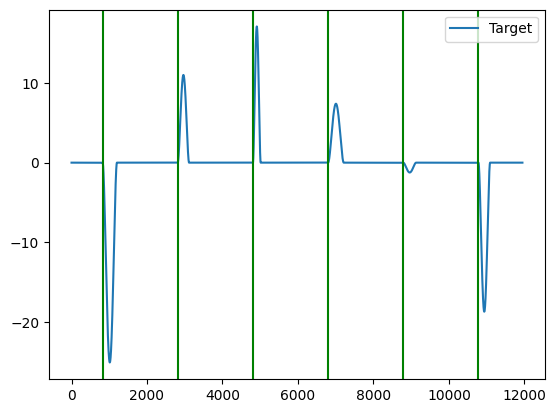

In [191]:
lower_bound = 0
upper_bound = -1

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i in start_indexes:
    plt.axvline(i, color="g")

plt.legend()

In [192]:
def determine_movement_ends(joint_vels: np.ndarray, start_indexes: list, threshold=1e-3, window=5):
    end_timestamps = []
    
    # Combine into a single speed since every joint finishes moving at the same time
    speed = np.linalg.norm(joint_vels, axis=1)
    
    for i in start_indexes:
        # Only look at data occurring after the start of this specific movement
        post_start_speed = speed[i:]
        
        # Find where speed drops below the threshold
        under_threshold = post_start_speed < threshold
        
        # To avoid mid-motion zero-crossings, ensure speed stays low for 'window' frames
        # We use a logical convolution to find a sequence of 'True' values
        is_settled = np.convolve(under_threshold, np.ones(window), mode='valid') == window
        
        # Find the first index where the 'settled' condition is met
        settled_indices = np.where(is_settled)[0]
        
        if settled_indices.size > 0:
            # We add 'ts' to get the global index, and 'window' isn't strictly 
            # necessary but helps point to the actual start of the stillness
            end_timestamps.append(i + settled_indices[0])
        else:
            # Fallback to end of array if no stop is detected
            end_timestamps.append(len(joint_vels) - 1)
            
    return end_timestamps

[824, 2814, 4806, 6798, 8789, 10782]
[1203, 3115, 5012, 7213, 9131, 11091]


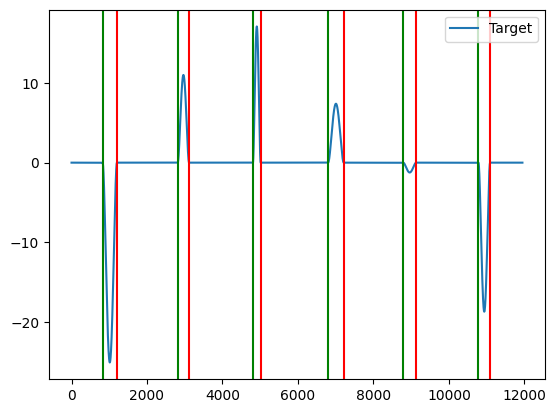

In [193]:
lower_bound = 0
upper_bound = -1

joint_vels = sensor_data_np[:, -6:]
joint_vels = joint_vels.astype(np.float64)

end_indexes = determine_movement_ends(joint_vels, start_indexes)

print(start_indexes)
print(end_indexes)

plt.plot(sensor_data_np[lower_bound:upper_bound, -1], label="Target")
for i, _ in enumerate(start_indexes):
    plt.axvline(start_indexes[i], color="g")
    plt.axvline(end_indexes[i], color="r")


plt.legend()

# Declaring data needed for training

We want to train a model to predict the time it takes to do a certain movement. Thus we now need to extract, the time a movement takes, and the start and end position

In [ ]:
# Extract time
# This is easy as it is just the difference between the start and end timesteps of movements
start_positions = []
end_positions = []
movement_time = []

joint_positions = sensor_data_np[:, -12:-6]

for i, _ in enumerate(start_indexes):
    # Determine time taken
    time_taken = sensor_data_np[end_indexes[i], 2] - sensor_data_np[start_indexes[i], 2]
    movement_time.append(time_taken.total_seconds()) # save time taken in seconds

    # Extract start and end pos
    start_pos = joint_positions[start_indexes[i], :]
    start_positions.append(start_pos)

    end_pos = joint_positions[end_indexes[i], :]
    end_positions.append(end_pos)


print(f"{movement_time=}\n")
print(f"{start_positions=}\n")
print(f"{end_positions=}\n")

movement_time=[Timedelta('0 days 00:00:19.039240'), Timedelta('0 days 00:00:15.114331'), Timedelta('0 days 00:00:10.329932'), Timedelta('0 days 00:00:20.853967'), Timedelta('0 days 00:00:17.155998'), Timedelta('0 days 00:00:15.526432')]

start_positions=[array([-9.604143947517752, -2.2314631294947587, -11.185124446370127,
       10.59809071101099, -5.795069639820377, -6.612752966697086],
      dtype=object), array([5.329275811873302, 5.893168185962159, -5.511988232650152,
       10.294209353473299, -1.4701505627087454, -0.7411151825617645],
      dtype=object), array([-2.852791627955736, -3.6159683994095877, -0.6798000596028715,
       0.32010797750477454, -9.57480811529264, 8.377037198911829],
      dtype=object), array([-11.16801250255556, -5.803779363344074, -12.398068565822452,
       4.3012038878469605, 11.342488463997608, 12.323148154396067],
      dtype=object), array([-3.5229690068179553, 11.310666424511455, -10.874866883885893,
       6.381521812606488, -2.9478084758669163, 11

In [213]:
max_position_diff = []

for i, _ in enumerate(start_positions):
    max_position_diff.append(np.max(np.abs(end_positions[i] - start_positions[i])))

max_position_diff

[3.558193962138745e-06,
 3.7916581756558543e-06,
 3.092437799168124e-06,
 3.150926199069204e-06,
 4.053835144901541e-06,
 5.1327418333357855e-06]

TypeError: float() argument must be a string or a real number, not 'Timedelta'

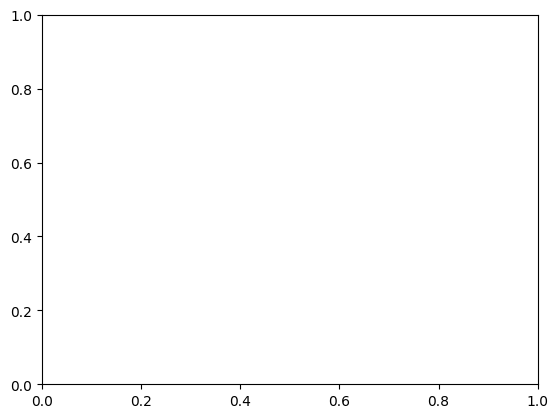

In [214]:
plt.plot(max_position_diff, movement_time)